# 2. Data Understanding

The focus for the Data Understanding phase is to discover underlying patterns in the data that may help us with decision making in the Data Preparation phase.

## 2.1. Collect Initial Data

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
ds = pd.read_excel("../data/campaign.xlsx")
ds.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635.0,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11.0,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426.0,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11.0,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173.0,...,5,0,0,0,0,0,0,3,11,0


## 2.2. Describe data

### Dataset description

    1. Campaign Interaction
- **AcceptedCmp1** - 1 if customer accepted the offer in the 1st campaign, 0 otherwise 
- **AcceptedCmp2** - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise 
- **AcceptedCmp3** - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise 
- **AcceptedCmp4** - 1 if customer accepted the offer in the 4th campaign, 0 otherwise 
- **AcceptedCmp5** - 1 if customer accepted the offer in the 5th campaign, 0 otherwise 
- **Response (target)** - 1 if customer accepted the offer in the last campaign, 0 otherwise 



`2. Customer Demographics`
- **Education** - customer’s level of education
- **Marital_Status** - customer’s marital status
- **Income** - customer’s yearly household income



`3. Household Composition`
- **Kidhome** - number of small children in customer’s household
- **Teenhome** - number of teenagers in customer’s household



`4. Spending Behaviour`
- **MntFishProducts** - amount spent on fish products in the last 2 years
- **MntMeatProducts** - amount spent on meat products in the last 2 years
- **MntFruits** - amount spent on fruits products in the last 2 years
- **MntSweetProducts** - amount spent on sweet products in the last 2 years
- **MntWines** - amount spent on wine products in the last 2 years
- **MntGoldProds** - amount spent on gold products in the last 2 years



`5. Purchase Behaviour`
- **Year_Birth** - customer's birth year
- **NumDealsPurchases** - number of purchases made with discount
- **NumCatalogPurchases** - number of purchases made using catalogue
- **NumStorePurchases** - number of purchases made directly in stores
- **NumWebPurchases** - number of purchases made through company’s web site

    
    
`6. Engagement and Digital Behaviour`
- **NumWebVisitsMonth** - number of visits to company’s web site in the last month

    
    
`7. Recency andLoyalty`
- **DtCustomer** - date of customer’s enrolment with the company
- **Recency** - number of days since the last purchase

    
    
`8. Customer Satisfaction`
- **Complain** - 1 if customer complained in the last 2 years

In [3]:
print(f'Dataset contains {ds.shape[0]} observations and {ds.shape[1]} columns.')
columns = ds.columns
display(columns)
ds.info()

Dataset contains 2240 observations and 29 columns.


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2237 non-null   float64
 10  MntFruits            2238 non-null   float64
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2187 non-null   float64
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Number of missing values in each variables
ds.isnull().sum().sort_values(ascending=False)

MntGoldProds           53
Income                 24
MntWines                3
MntFruits               2
NumWebPurchases         0
Z_Revenue               0
Z_CostContact           0
Complain                0
AcceptedCmp2            0
AcceptedCmp1            0
AcceptedCmp5            0
AcceptedCmp4            0
AcceptedCmp3            0
NumWebVisitsMonth       0
NumStorePurchases       0
NumCatalogPurchases     0
ID                      0
NumDealsPurchases       0
Year_Birth              0
MntSweetProducts        0
MntFishProducts         0
MntMeatProducts         0
Recency                 0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Marital_Status          0
Education               0
Response                0
dtype: int64

In [5]:
# Number of duplicates
ds.duplicated().sum()

np.int64(0)

#### Key Findings:
- The dataset contains 2240 observations and 29 variables.
- Missing values are concentrated in the variables:
    - Income (24 missing)
    - MntGoldProds (53 missing)
    - MntWines (3 missing)
    - MntFruits (2 missing)

- The majority of variables are numerical, with only 3 categorical variables: Education, Marital_Status, Dt_Customer

- Dt_Customer is stored as object, although it represents date information.

- ID acts only as a customer identifier and does not provide predictive information.

- There are no duplicate values in this dataset.

In [6]:
# Summary statistics
ds.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2237.0,303.838623,336.576209,0.0,24.00,173.0,504.00,1493.0
MntFruits,2238.0,26.252011,39.699755,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.523661,54.630198,-1.0,3.00,12.0,50.00,259.0


- `Z_CostContact` and `Z_Revenue` have constant values, therefore they provide no useful information for modelling.

- Income shows at least one extreme outlier, with a maximum value of 666,666, indicating strong right skew.

- Most spending variables appear highly right-skewed, as their means are consistently higher than their medians, suggesting that spending is concentrated among a relatively small number of customers.

- `MntSweetProducts` contains implausible extreme values, with a maximum of 23,423,444 and an unusually large standard deviation.

- `MntFishProducts` includes negative values (min = -1) which are not plausible.

- `Year_Birth` contains an extreme minimum value (1893), which is unrealistic.

# 2.3. Explore data

## 2.3.1. Univariate Analysis

## A. Categorical variables

In [7]:
categorical_cols = ds.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('Dt_Customer', errors='ignore')

# Checking counts and their percentage
for col in categorical_cols:
    print(f'\n------{col}-------\n')
    print(ds[col].value_counts(dropna=False))
    print(f'\n------{col} percentage-------\n')
    print(ds[col].value_counts(normalize=True, dropna=False))


------Education-------

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

------Education percentage-------

Education
Graduation    0.503125
PhD           0.216964
Master        0.165179
2n Cycle      0.090625
Basic         0.024107
Name: proportion, dtype: float64

------Marital_Status-------

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

------Marital_Status percentage-------

Marital_Status
Married     0.385714
Together    0.258929
Single      0.214286
Divorced    0.103571
Widow       0.034375
Alone       0.001339
Absurd      0.000893
YOLO        0.000893
Name: proportion, dtype: float64


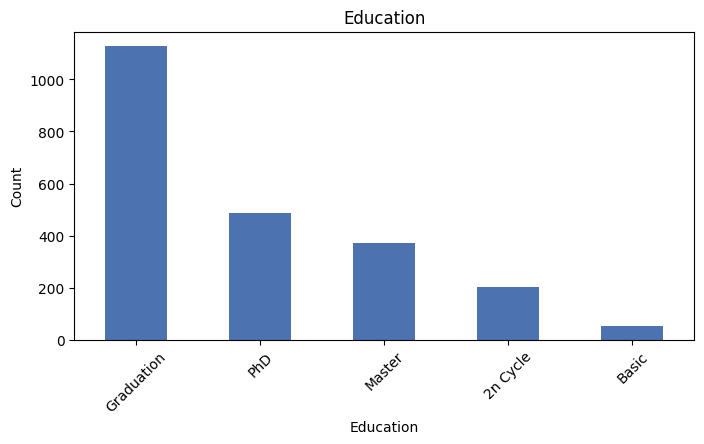

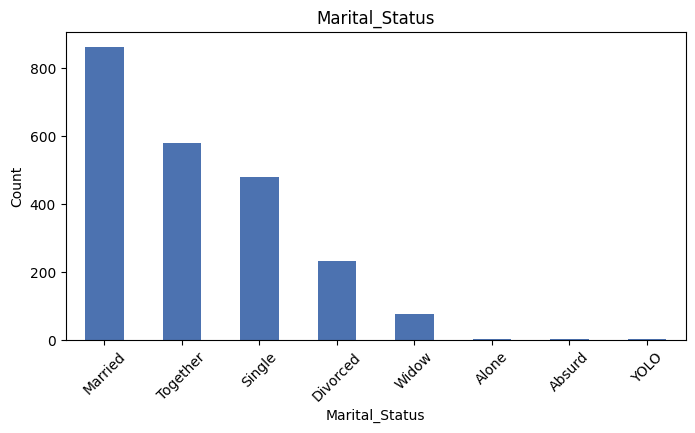

In [8]:
sns.set_palette("deep")

for col in categorical_cols:
    
    plt.figure(figsize=(8, 4))
    ds[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

#### Key Findings:

The categorical analysis shows an uneven distribution across categories. Education is largely dominated by Graduation, followed by PhD and Master, while the categories Basic and 2n Cycle represent only a small share of customers. A similar pattern is observed in Marital_Status, where Married, Together, and Single account for most observations. Categories Alone, Absurd, and YOLO contain very few records. 
Dt_Customer was not explored in this section as its current format did not allow for a good interpretation of the variable.


## B. Numerical Variables

For the numerical univariate analysis, the binary variables AcceptedCmp1–5, Complain, and Response were excluded as they will be assessed next.

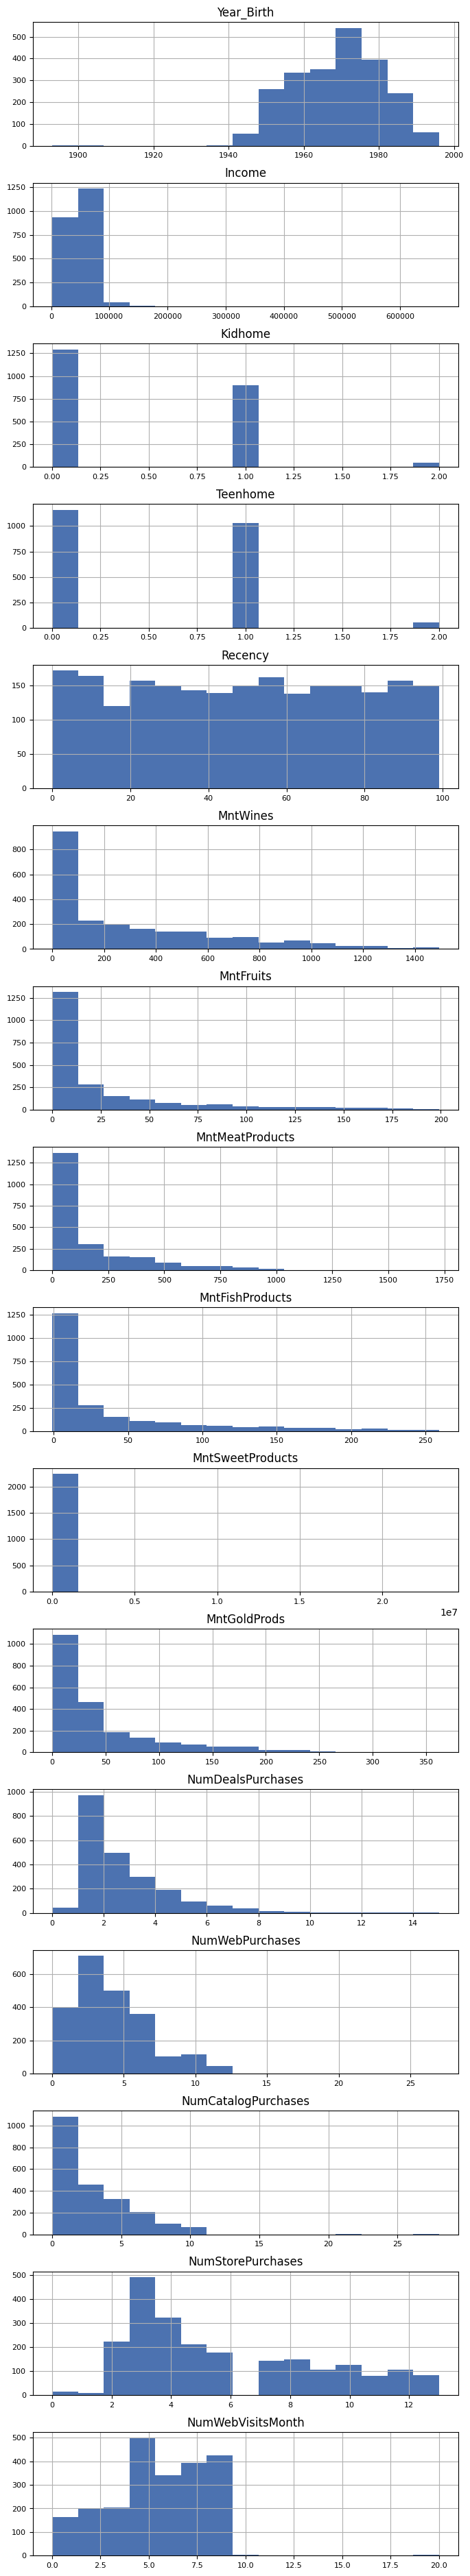

In [9]:
numerical_cols = ds.select_dtypes(include=[np.number]).columns
numerical_cols = numerical_cols.drop(['ID', 'Z_Revenue', 'Z_CostContact','AcceptedCmp2', 'AcceptedCmp1', 'AcceptedCmp5', 'AcceptedCmp4', 'AcceptedCmp3', 'Complain', 'Response'], errors='ignore')
ds[numerical_cols].hist(bins=15, figsize=(8, 3*len(numerical_cols)), layout=(len(numerical_cols), 1), xlabelsize=8, ylabelsize=8);

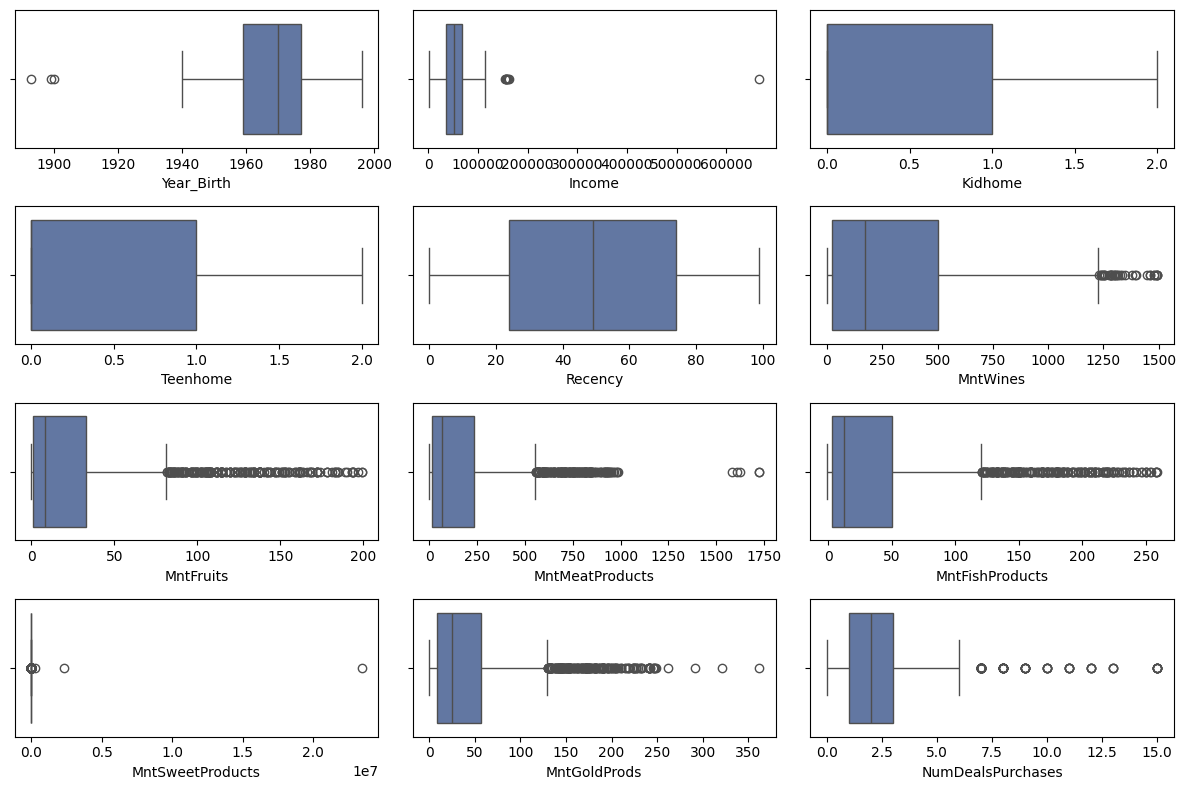

In [10]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8))

for var, subplot in zip(numerical_cols, ax.flatten()):
    sns.boxplot(x=ds[var], ax=subplot, color="#5773ad")
    
plt.tight_layout()
plt.show()

#### Key Findings:

The numerical variables show several non-normal distributions and a large presence of outliers. Most spending variables are strongly right-skewed, indicating that most customers spend relatively low amounts and a smaller group spends substantially more. The boxplots confirm this pattern. 

Income follows a similar distribution, with clear extreme values. 

As seen before, MntSweetProducts stands out due to an exceptionally large value. 

Recency appears more evenly distributed and does not show strong outliers. 

Kidhome and Teenhome are concentrated around values of 0 and 1, so most customers have no more than one child or teenager in the household. 

Purchase-related variables are moderately right-skewed: most customers make relatively few purchases. 

`Year_Birth` confirms the presence of unrealistic ages and potential outliers.

## C. Binary Variables

In [11]:
binary_cols = [col for col in ds.columns if ds[col].nunique() == 2]
binary_cols.remove('Response')

# checking counts of zeros and ones and their proportion within the variable
for col in binary_cols:
    
    counts = ds[col].value_counts()
    proportions = ds[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({'Count': counts, 'Proportion': proportions})
    
    print(f'\n-------{col}-------\n')
    print(summary)


-------AcceptedCmp3-------

              Count  Proportion
AcceptedCmp3                   
0              2077   92.723214
1               163    7.276786

-------AcceptedCmp4-------

              Count  Proportion
AcceptedCmp4                   
0              2073   92.544643
1               167    7.455357

-------AcceptedCmp5-------

              Count  Proportion
AcceptedCmp5                   
0              2077   92.723214
1               163    7.276786

-------AcceptedCmp1-------

              Count  Proportion
AcceptedCmp1                   
0              2096   93.571429
1               144    6.428571

-------AcceptedCmp2-------

              Count  Proportion
AcceptedCmp2                   
0              2210   98.660714
1                30    1.339286

-------Complain-------

          Count  Proportion
Complain                   
0          2219     99.0625
1            21      0.9375


#### Key Findings:

The binary variables are highly imbalanced and largely dominated by the value 0. Across all previous campaign variables (AcceptedCmp1–5), only a small proportion of customers accepted earlier offers, with acceptance rates ranging from 1.3% (AcceptedCmp2) to approximately 7.5% (AcceptedCmp3–5). AcceptedCmp2 is particularly sparse, with very few positive cases. Similarly, Complain is extremely imbalanced, with only 0.94% of customers having submitted complaints. Overall, these variables represent rare events.

## D. Target Variable Analysis

,Count,Proportion %
Response,,
0,1906,85.09
1,334,14.91


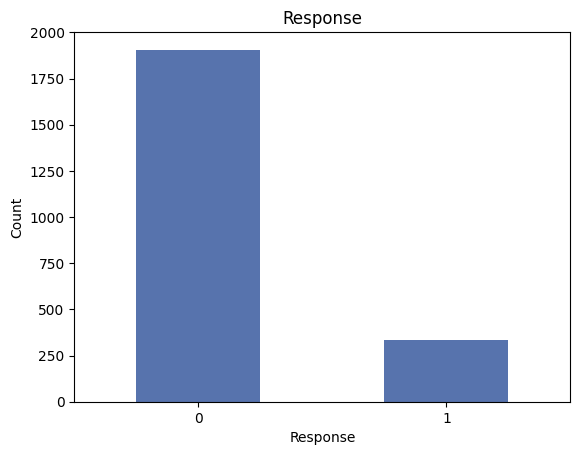

In [12]:
# Distribution
target_summary = pd.DataFrame({
    'Count': ds['Response'].value_counts(),
    'Proportion %': (ds['Response'].value_counts(normalize=True) * 100).round(2)
})

display(target_summary)

# visualization of the class imbalance
ds['Response'].value_counts().plot(kind='bar', color='#5773ad')
plt.title('Response')
plt.ylabel('Count')
plt.xticks(rotation=0);

#### Key Findings:

- The target variable Response shows a clear class imbalance. Most customers (85.1%) did not accept the latest campaign offer, while only 14.9% responded positively.

- The bar plot confirms this imbalance, with the non-response class largely dominating the dataset.

# 2.3.2. Bivariate Analysis

After understanding each variable individually, the next step is to compare customer characteristics against the target variable, `Response`, to identify which profiles are more associated with campaign acceptance.

## Numerical vs Response

For this analysis, the relationship between the numerical variables and the target variable (Response) will be explored. (Year_Birth was excluded, as in its current format it is less interpretable than a derived age variable and may provide more meaningful insights after feature engineering in later stages.)

### A. Continuous Variables

In [13]:
continuous_vars = [
    'Income',
    'Recency',
    'MntWines',
    'MntMeatProducts',
    'MntGoldProds',
    'MntFishProducts',
    'MntSweetProducts',
    'MntFruits'
]

display(ds.groupby('Response')[continuous_vars].mean().round(2).T)
display(ds.groupby('Response')[continuous_vars].median().round(2).T)

Response,0,1
Income,50839.13,60209.68
Recency,51.51,35.38
MntWines,268.94,502.70
MntMeatProducts,144.62,294.35
MntGoldProds,41.56,61.81
MntFishProducts,34.98,52.04
MntSweetProducts,1376.89,70168.11
MntFruits,24.22,37.86


Response,0,1
Income,50150.0,64090.0
Recency,52.0,30.0
MntWines,152.0,448.0
MntMeatProducts,56.0,174.5
MntGoldProds,21.0,39.5
MntFishProducts,11.0,25.0
MntSweetProducts,7.0,20.0
MntFruits,7.0,21.0


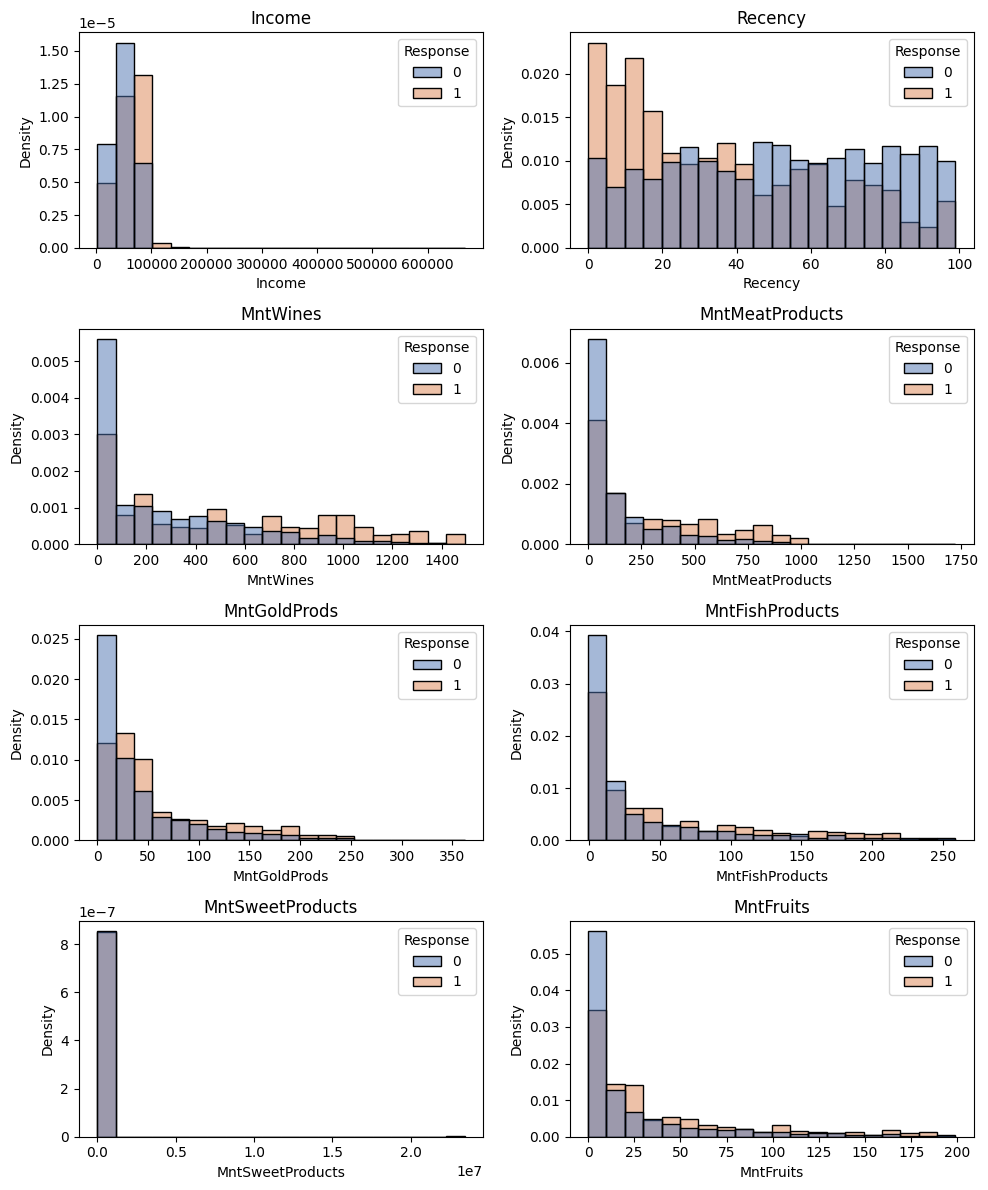

In [14]:
fig, ax = plt.subplots(4, 2, figsize=(10, 12))

for var, subplot in zip(continuous_vars, ax.flatten()):
    
    sns.histplot(
        data=ds,
        x=var,
        hue='Response',
        stat='density',
        common_norm=False,
        bins=20,
        alpha=0.5,
        ax=subplot
    )

    subplot.set_title(var)

plt.tight_layout()
plt.show()

#### Key Findings:

- Customers who responded to the campaign generally show higher income levels and higher spending across all product categories compared to non-responders.

- Recency shows the clearest separation between groups. Responders are concentrated at lower recency, so customers who purchased more recently are more likely to accept campaign offers.

- `MntWines` and `MntMeatProducts` display the strongest spending differences, with responders showing noticeably higher spending distributions. `MntGoldProds`, `MntFishProducts`, and `MntFruits` follow a similar pattern, although the separation between groups is less pronounced.

### B. Purchase Frequency Variables

In [15]:
count_vars = [
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumWebVisitsMonth'
]

display(ds.groupby('Response')[count_vars].mean().T)

Response,0,1
NumCatalogPurchases,2.391920,4.203593
NumStorePurchases,5.736621,6.095808
NumDealsPurchases,2.323190,2.335329
NumWebPurchases,3.911857,5.071856
NumWebVisitsMonth,5.320567,5.293413


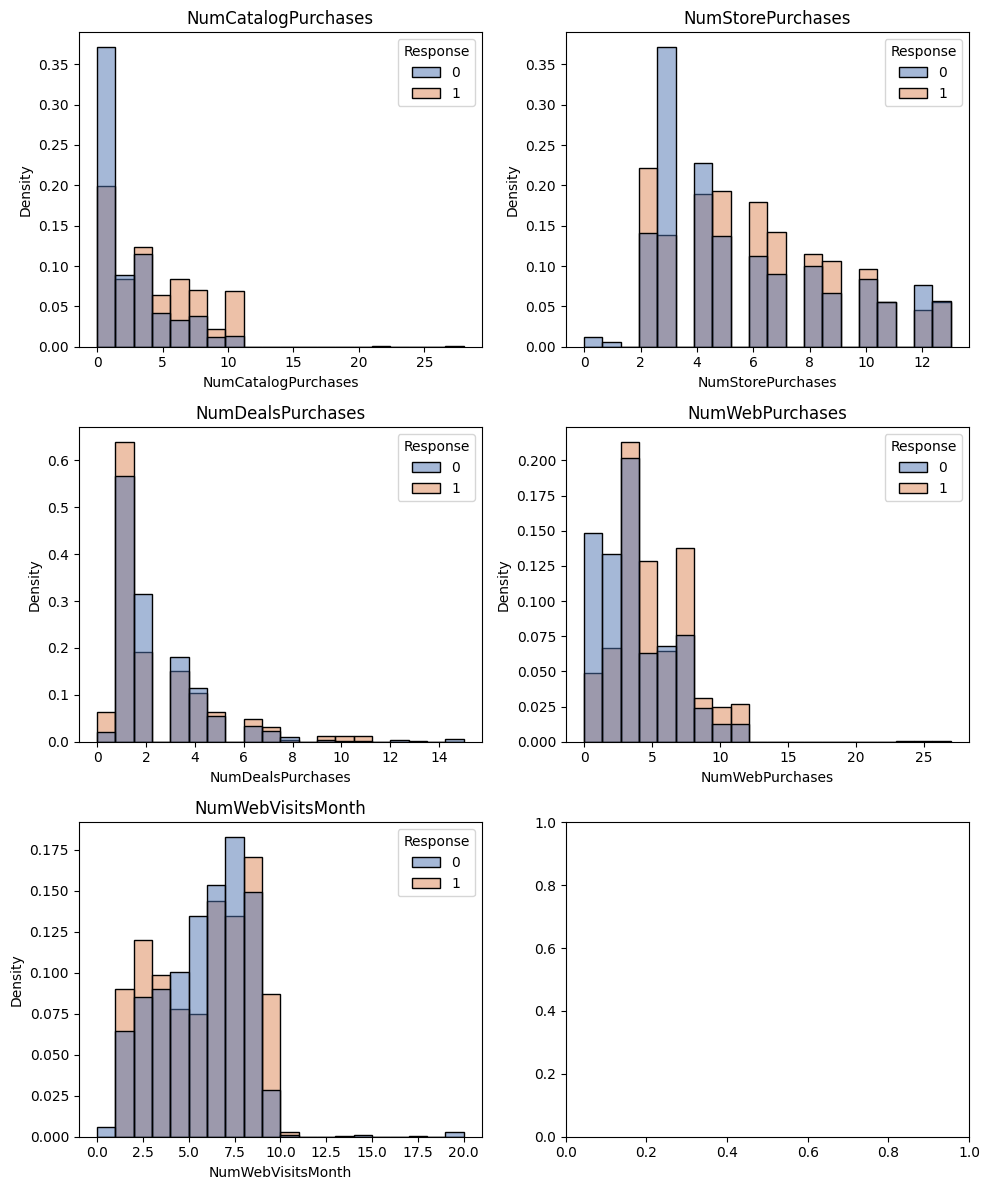

In [16]:
fig, ax = plt.subplots(3, 2, figsize=(10, 12))

for var, subplot in zip(count_vars, ax.flatten()):
    
    sns.histplot(
        data=ds,
        x=var,
        hue='Response',
        stat='density',
        common_norm=False,
        bins=20,
        alpha=0.5,
        ax=subplot
    )

    subplot.set_title(var)

plt.tight_layout()
plt.show()

#### Key Findings: 

- `NumCatalogPurchases` shows the clearest difference between groups. Responders make substantially more catalog purchases on average, with the distribution shifted toward higher values.

- `NumWebPurchases` also shows a noticeable difference, with responders making more online purchases.

- `NumDealsPurchases` and `NumWebVisitsMonth` show almost identical distributions between groups, suggesting a weak relationship with campaign response.


**Overall, customers who responded appear to be more active purchasers, particularly through catalog and online channels.**

### C. Household Composition Variables

In [17]:
household_vars = [
    'Kidhome',
    'Teenhome'
]

for col in household_vars:
    display(
        pd.crosstab(
            ds[col],
            ds['Response'],
            normalize='index'
        )
    )

Response,0,1
Kidhome,,
0,0.828306,0.171694
1,0.877642,0.122358
2,0.958333,0.041667


Response,0,1
Teenhome,,
0,0.795337,0.204663
1,0.910680,0.089320
2,0.903846,0.096154


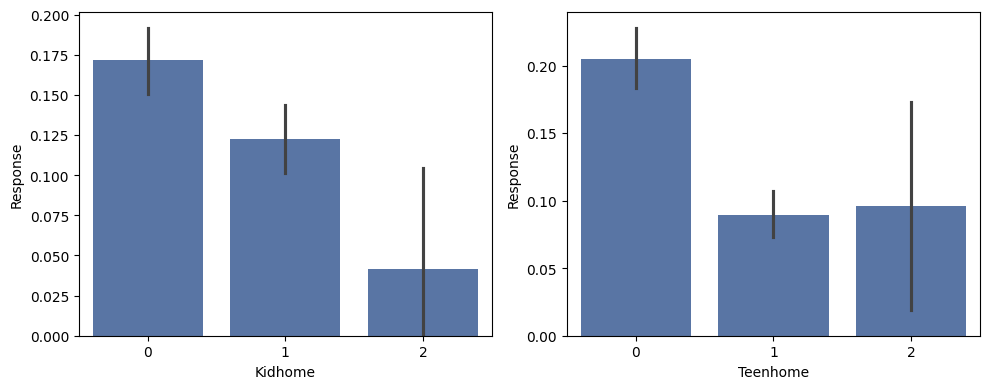

In [18]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

for var, subplot in zip(household_vars, ax.flatten()):
    sns.barplot(
        x=var,
        y='Response',
        data=ds,
        ax=subplot
    )

plt.tight_layout()

#### Key Findings:

- Kidhome shows a clear pattern: response rates drop as the number of children increases. Customers with no children at home have the highest response rate, while customers with one child and two children respond less often.

- Teenhome shows a similar trend. Customers with no teenagers at home have the highest response rate, while households with one or two teenagers respond much less.

**Overall, customers without children or teenagers in the household seem more likely to respond to campaign offers.**

## Categorical vs Response

In [19]:
# response rate by class
for col in categorical_cols:
    
    print(f"\n{col}")
    
    display(pd.crosstab(
            ds[col],
            ds['Response'],
            normalize='index'
        ))


Education


Response,0,1
Education,,
2n Cycle,0.891626,0.108374
Basic,0.962963,0.037037
Graduation,0.865129,0.134871
Master,0.845946,0.154054
PhD,0.792181,0.207819



Marital_Status


Response,0,1
Marital_Status,,
Absurd,0.500000,0.500000
Alone,0.666667,0.333333
Divorced,0.793103,0.206897
Married,0.886574,0.113426
Single,0.779167,0.220833
Together,0.896552,0.103448
Widow,0.753247,0.246753
YOLO,0.500000,0.500000


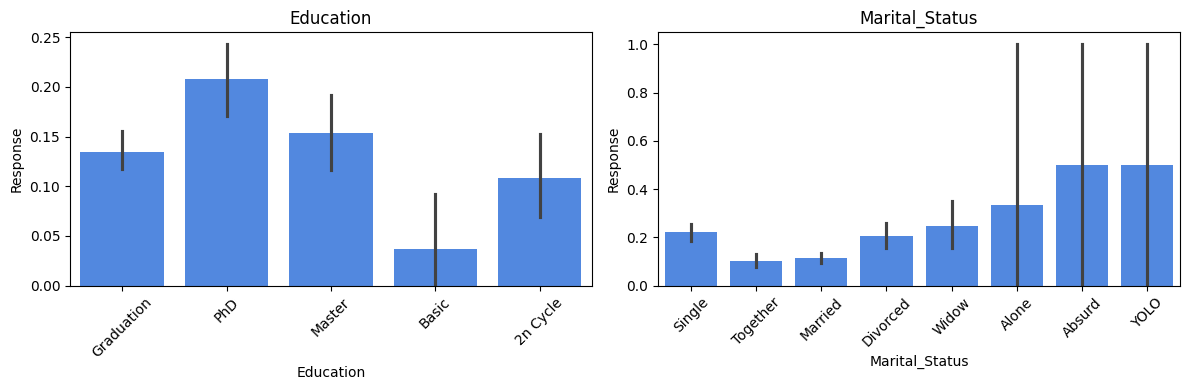

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

for var, subplot in zip(categorical_cols, ax.flatten()):
    
    sns.barplot(
        x=var,
        y='Response',
        data=ds,
        ax=subplot,
        color='#3b82f6'
    )
    
    subplot.set_title(var)
    subplot.tick_params(axis='x', rotation=45)
plt.tight_layout()

#### Key Findings:

- Education shows some differences across groups. Customers with a PhD have the highest response rate (20.8%), followed by Master (15.4%), while Basic has the lowest (3.7%). Response rates appear to increase with higher education levels.

- For Marital_Status, Single, Divorced, and Widow customers show higher response rates than Married and Together customers.

- Categories Alone, Absurd, and YOLO show unusually high response rates, but they have very few observations and are therefore not reliable for interpretation.

## Campaign Variables vs Response

Among customers who accepted / did not accept a previous campaign, what proportion responded now?

In [21]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

campaign_summary = pd.DataFrame({
    col: ds.groupby(col)['Response'].mean()
    for col in campaign_cols
}).T
campaign_summary['Lift'] = (
    campaign_summary[1] /
    campaign_summary[0]
).round(2)

campaign_summary

,0,1,Lift
AcceptedCmp1,0.121660,0.548611,4.51
AcceptedCmp2,0.142081,0.666667,4.69
AcceptedCmp3,0.123736,0.472393,3.82
AcceptedCmp4,0.131211,0.371257,2.83
AcceptedCmp5,0.116514,0.564417,4.84


#### Key Findings:

1. Customers who accepted a previous campaign consistently show much higher response rates than those who did not.

2. `AcceptedCmp5` shows the strongest effect: customers who accepted Campaign 5 were 4.8 times more likely to respond to the current campaign.

## 2.3.3. Multivariate Analysis

After exploring individual variables and their relationship with the target, the next step is to assess relationships between variables and identify potential redundancy.

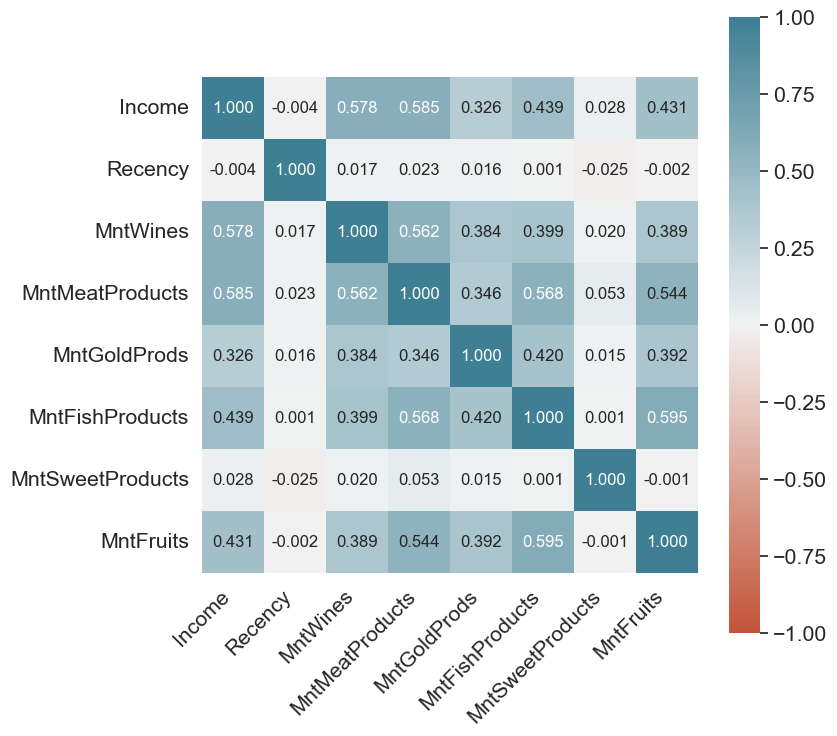

In [22]:
corr_vars = continuous_vars

corr_matrix = ds[corr_vars].corr()

plt.figure(figsize=(8, 8))
sns.set(font_scale=1.4)
ax = sns.heatmap(
    corr_matrix, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True, annot_kws={"size": 12},
    fmt='.3f'
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

The correlation matrix shows that spending variables tend to be related to each other. Customers who spend more in one product category generally also spend more in others. Income is moderately related to spending, especially for MntMeatProducts and MntWines, suggesting that higher-income customers tend to spend more overall. Some product categories, such as MntFishProducts and MntFruits, also show relatively strong relationships, which suggests similar purchasing patterns. On the other hand, Recency shows almost no relationship with the remaining variables. MntSweetProducts also behaves differently from the other spending variables, which is consistent with the unusual values identified earlier.

## 2.4. Verify data quality

After exploring the dataset, additional checks were performed to verify consistency, plausibility, and potential quality issues identified during the previous analysis.

### A. Duplicate Checks

Since a general duplicate assessment was already previously done, only ID was assessed for possible duplicate records. None were found.

In [23]:
ds['ID'].duplicated().sum()

np.int64(0)

### B. Plausibility Checks

### MntSweetProducts

The unusually large values previously identified were further investigated.

In [24]:
ds['MntSweetProducts'].sort_values(ascending=False).head(10)

634     23423444
523      2342344
563       234444
27           263
1898         262
1513         197
1671         196
1253         195
456          194
2012         194
Name: MntSweetProducts, dtype: int64

The amount of values above the third quantile was inspected.

In [25]:
Q1 = ds['MntSweetProducts'].quantile(0.25)
Q3 = ds['MntSweetProducts'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5*IQR

(ds['MntSweetProducts'] > upper).sum()

np.int64(249)

The record containing the maximum value was also inspected.

In [26]:
ds.loc[ds['MntSweetProducts']==ds['MntSweetProducts'].max()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
634,8923,1973,Graduation,Single,83917.0,0,0,2013-04-18,12,514.0,...,3,0,0,0,0,0,0,3,11,1


#### Key Findings:

MntSweetProducts shows clear signs of data quality issues. Although the IQR method identified 249 observations above the upper outlier threshold, inspection of the values shows that only a few observations are extremely different from the rest of the distribution. While most customers spend below 300, values such as 234,444, 2,342,344, and 23,423,444 were identified, followed by a sharp drop to values around 200–260. This large gap suggests that these observations are more likely to be recording errors or anomalous values. Inspection of the customer with the maximum value did not reveal unusual patterns in the remaining variables.

### Year_Birth

In [27]:
ds['Year_Birth'].value_counts().sort_index().head(15)

Year_Birth
1893     1
1899     1
1900     1
1940     1
1941     1
1943     7
1944     7
1945     8
1946    16
1947    16
1948    21
1949    30
1950    29
1951    43
1952    52
Name: count, dtype: int64

#### Key Findings:

`Year_Birth` contains a small number of unusually old values, specifically 1893, 1899, and 1900, each appearing only once. Since these values are isolated observations and imply customer ages above 120 years, they are likely anomalous records.

### MntFishProducts

In [28]:
ds['MntFishProducts'].sort_values().head(10)
(ds['MntFishProducts'] < 0).sum()

np.int64(2)

`MntFishProducts` contains 2 negative values, which are not plausible for spending variables.

## Final Balance of Data Quality


| Issue                                   | Variable(s)                                       |
| --------------------------------------- | ------------------------------------------------- |
| Missing values                          | `Income`, `MntGoldProds`, `MntWines`, `MntFruits` |
| Constant values                         | `Z_CostContact`, `Z_Revenue`                      |
| Extreme values / anomalous observations | `MntSweetProducts`, `Income`                      |
| Negative values                         | `MntFishProducts`                                 |
| Unrealistic birth years                 | `Year_Birth`                                      |
| Rare / inconsistent labels              | `Marital_Status`                                  |
| Incorrect data type                     | `Dt_Customer`                                     |
| Class imbalance                         | `Response`, `AcceptedCmp1–5`, `Complain`          |


## Key Findings from Data Understanding

- The target variable (`Response`) is highly imbalanced, with only **14.9%** of customers accepting the latest campaign offer.

- Customers who responded generally have **higher income levels** and **higher spending across most product categories**, particularly `MntWines` and `MntMeatProducts`.

- `Recency` shows one of the clearest patterns: customers who purchased more recently appear more likely to respond to campaign offers.

- Responders also show **higher purchasing activity**, especially through **catalog** and **web channels**.

- Household composition appears relevant, as customers with **no children or teenagers at home** tend to have higher response rates.

- Previous campaign behavior is one of the strongest indicators of future response. Customers who accepted earlier campaigns were substantially more likely to respond again.

- Education and marital status show some relationship with response behavior. Higher education levels generally correspond to higher response rates, while `Single`, `Divorced`, and `Widow` customers tend to respond more often than `Married` and `Together` customers.